In [12]:
# Imports
import os
import sys
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Import from wasp package
from wasp.io_sar import load_sar_spectrum
from wasp.wave_params import calculate_wave_parameters
from wasp.partition import partition_spectrum
from wasp.plotting import plot_directional_spectrum
from wasp.utils import load_config, spectrum1d_from_2d


## 1. Configuration and Data Loading

Loading Sentinel-1 SAR spectral data from local file using wasp functions.

In [13]:
# ============================================================================
# LOAD CONFIGURATION
# ============================================================================
CONFIG = load_config('config.yaml')

# Partitioning parameters (from config.yaml)
MIN_ENERGY_THRESHOLD_FRACTION = CONFIG['partitioning']['sar']['min_energy_fraction']
MAX_PARTITIONS = CONFIG['partitioning']['sar']['max_partitions']
THRESHOLD_PERCENTILE = CONFIG['partitioning']['sar']['threshold_percentile']
MERGE_FACTOR = CONFIG['partitioning']['sar']['merge_factor']

# Plotting parameters (from config.yaml)
PLOT_PERIOD_MAX = CONFIG['plotting']['sar'].get('period_max', 25)

print(f"  threshold_percentile = {THRESHOLD_PERCENTILE}")
print(f"  merge_factor = {MERGE_FACTOR}")
print(f"  max_partitions = {MAX_PARTITIONS}")
print(f"  min_energy_fraction = {MIN_ENERGY_THRESHOLD_FRACTION}")


  threshold_percentile = 98
  merge_factor = 0.3
  max_partitions = 3
  min_energy_fraction = 0.01


## 2. Load SAR Spectrum

Sentinel-1 SAR data (CMEMS format, group `obs_params`) provides:
- `wave_spec` : 2D spectrum E(k,θ) [m⁴] in wavenumber × direction space
- `wavenumber_spec` / `direction_spec` : spectral axes
- `VAVH`, `VTPK`, `VPED` : integrated parameters (Hs, Tp, Dp) from the SAR processor
- `L2_partition_quality_flag` : quality control flag per observation

The spectrum is converted to E(f,θ) [m²·s·rad⁻¹] using the dispersion-relation Jacobian |dk/df| = 8π²f/g.

In [14]:
# ============================================================================
# LOAD SAR SPECTRUM FROM LOCAL FILE
# ============================================================================
file_path = '../data/sentinel_sar.nc'
grp = "obs_params"

# Spatial index: each observation = one SAR image acquisition (location + time)
index = 18

# Open the SAR dataset (Sentinel-1 CMEMS format uses group "obs_params")
ds = xr.open_dataset(file_path, group=grp)

# Load and convert 2D spectrum: E(k,θ) [m⁴] → E(f,θ) [m²·s·rad⁻¹]
E2d, freq, dirs, dirs_rad, selected_time = load_sar_spectrum(ds, date_time=None, index=index)

# Extract metadata from SAR file using the exact variable names
lon          = float(ds.longitude[index].values)
lat          = float(ds.latitude[index].values)
vavh_sar     = float(ds.VAVH[index].values)          # Hs from SAR file [m]
vtpk_sar     = float(ds.VTPK[index].values)          # Tp from SAR file [s]
vped_sar     = float(ds.VPED[index].values)          # Dp from SAR file [°]
quality_flag = int(ds.L2_partition_quality_flag[index].values)

print(f"File: {os.path.basename(file_path)}")
print(f"Spatial index: {index}")
print(f"Timestamp: {selected_time}")
print(f"Location: {lon:.2f}°E, {lat:.2f}°N")
print(f"Quality flag (L2_partition_quality_flag): {quality_flag}")
print(f"\nFrequencies: {len(freq)} bins ({freq[0]:.4f} – {freq[-1]:.4f} Hz)")
print(f"Directions:  {len(dirs)} bins ({dirs[0]:.1f}° – {dirs[-1]:.1f}°)")
print(f"E2d shape: {E2d.shape}")


Available variables in SAR file: ['L2_source_product', 'VPED', 'snr', 'VTPK', 'partition_domain_spec', 'VPED_flag', 'L2_partition_quality_flag', 'n_posneg', 'n_box', 'direction_spec', 'longitude', 'inten', 'VAVH_flag', 'wavenumber_spec', 'storm_id', 'latitude', 'nv', 'VTPK_flag', 'VAVH', 'time', 'resolution_spec', 'wave_spec']
Usando file preprocessado (CMEMS), shape E_sar: (60, 72)
Shape k: (60,)
Shape phi: (72,)
╔══════════════════════════════════════════════════════════════╗
║         SAR CONVERSION: m⁴ → m²·s·rad⁻¹ (WW3 units)          ║
╠══════════════════════════════════════════════════════════════╣
║ Shape:                                             (60, 72) ║
║ Frequencies: 60 bins | Directions: 72 bins              ║
║ Freq range: 0.0361 - 0.2281 Hz                       ║
║ Dir range: 0.0° - 355.0°                            ║
╟──────────────────────────────────────────────────────────────╢
║ Jacobiano dk/df: 0.2903 - 1.8361                   ║
║ Fator angular (π/180): 0.017

## 3. Calculate Integrated Wave Parameters

Calculate Hs, Tp, Dp from the 2D spectrum and compare to the SAR file values (VAVH/VTPK/VPED).

In [15]:
# Calculate Hs, Tp, Dp using trapezoidal integration
hs, tp, dp, m0, delf, ddir, i_peak, j_peak = calculate_wave_parameters(E2d, freq, dirs_rad)

print("\n" + "="*70)
print(" SAR SPECTRUM INTEGRATED PARAMETERS")
print("="*70)
print(f"Spatial index: {index}")
print(f"Location: {lon:.2f}°E, {lat:.2f}°N")
print(f"Time: {selected_time}")
print(f"Quality flag: {quality_flag}")
print("─"*70)

print(f"\nCalculated (from 2D spectrum):")
print(f"   m0 = {m0:.6f} m²")
print(f"   Hs = {hs:.2f} m")
print(f"   Tp = {tp:.2f} s")
print(f"   Dp = {dp:.0f}°")

print(f"\nSAR file (VAVH / VTPK / VPED):")
print(f"   Hs = {vavh_sar:.2f} m")
print(f"   Tp = {vtpk_sar:.2f} s")
print(f"   Dp = {vped_sar:.0f}°")

print(f"\n   ΔHs (calc vs file) = {abs(hs - vavh_sar) / vavh_sar * 100:.1f}%")
print("="*70)



 SAR SPECTRUM INTEGRATED PARAMETERS
Spatial index: 18
Location: -113.52°E, -4.92°N
Time: 2023-02-12 13:22:23
Quality flag: 4
──────────────────────────────────────────────────────────────────────

Calculated (from 2D spectrum):
   m0 = 0.156916 m²
   Hs = 1.58 m
   Tp = 14.38 s
   Dp = 5°

SAR file (VAVH / VTPK / VPED):
   Hs = 0.61 m
   Tp = 16.71 s
   Dp = -31°

   ΔHs (calc vs file) = 158.9%


## 4. Spectral Partitioning

Apply spectral partitioning to identify wave systems (swell and wind sea).

In [16]:
# ============================================================================
# APPLY PARTITIONING (parameters from config.yaml)
# ============================================================================
results = partition_spectrum(
    E2d, freq, dirs_rad,
    threshold_mode='adaptive',
    threshold_percentile=THRESHOLD_PERCENTILE,
    merge_factor=MERGE_FACTOR,
    max_partitions=MAX_PARTITIONS
)

if results is None:
    print("No spectral peaks identified!")
else:
    min_energy_threshold = MIN_ENERGY_THRESHOLD_FRACTION * results['total_m0']
    n_peaks_initial = len(results['peaks'])
    
    # Count significant partitions
    n_partitions_final = sum(
        1 for i in range(1, len(results['Hs']))
        if results['energy'][i] > min_energy_threshold
    )

    print("\n" + "="*70)
    print(" SPECTRAL PARTITIONING - PROCESS SUMMARY")
    print("="*70)
    print(f"Spectral peaks initially identified: {n_peaks_initial}")
    print(f"After merging nearby systems: {n_partitions_final} partition(s)")
    print("="*70)

    print("\n" + "="*70)
    print(" PARTITIONING RESULTS")
    print("="*70)
    print(f"Number of significant partitions: {n_partitions_final}")
    print("─"*70)

    partition_count = 0
    for i in range(1, len(results['Hs'])):
        if results['energy'][i] > min_energy_threshold:
            partition_count += 1
            energy_pct = (results['energy'][i] / results['total_m0']) * 100
            print(f"\nPartition {partition_count}:")
            print(f"  Hs = {results['Hs'][i]:.2f} m")
            print(f"  Tp = {results['Tp'][i]:.2f} s")
            print(f"  Dp = {results['Dp'][i]:.0f}°")
            print(f"  Energy: {results['energy'][i]:.4f} m² ({energy_pct:.1f}%)")

    print("\n" + "─"*70)
    print(f"Integrated total:")
    print(f"  Hs = {results['total_Hs']:.2f} m")
    print(f"  Tp = {results['total_Tp']:.2f} s")
    print(f"  Dp = {results['total_Dp']:.0f}°")
    print("="*70)

Adaptive threshold: 4.24e+00 (98.0th percentile)
Identifying spectral peaks with threshold: 4.24e+00
Spectrum values: min=0.00e+00, max=1.33e+01, mean=1.96e-01
Identified 2 spectral peaks
Generating mask from ICOD...
  ICOD propagation converged after 4 iterations
Calculating distances between peaks...
Calculating peak spreading...
Checking for overlapping systems (merge_factor=0.3)...
Number of masks: 2
[DEBUG] Sum of partition energies: 0.156916
[DEBUG] Expected total: 0.156916
Total spectrum energy: 0.156916
Sum of partitioned energies: 0.156916

 SPECTRAL PARTITIONING - PROCESS SUMMARY
Spectral peaks initially identified: 2
After merging nearby systems: 2 partition(s)

 PARTITIONING RESULTS
Number of significant partitions: 2
──────────────────────────────────────────────────────────────────────

Partition 1:
  Hs = 1.38 m
  Tp = 14.38 s
  Dp = 5°
  Energy: 0.1195 m² (76.2%)

Partition 2:
  Hs = 0.77 m
  Tp = 16.81 s
  Dp = 150°
  Energy: 0.0374 m² (23.8%)

────────────────────────

## 5. Plot Directional Spectrum

Polar plot showing energy distribution by frequency (period) and direction.

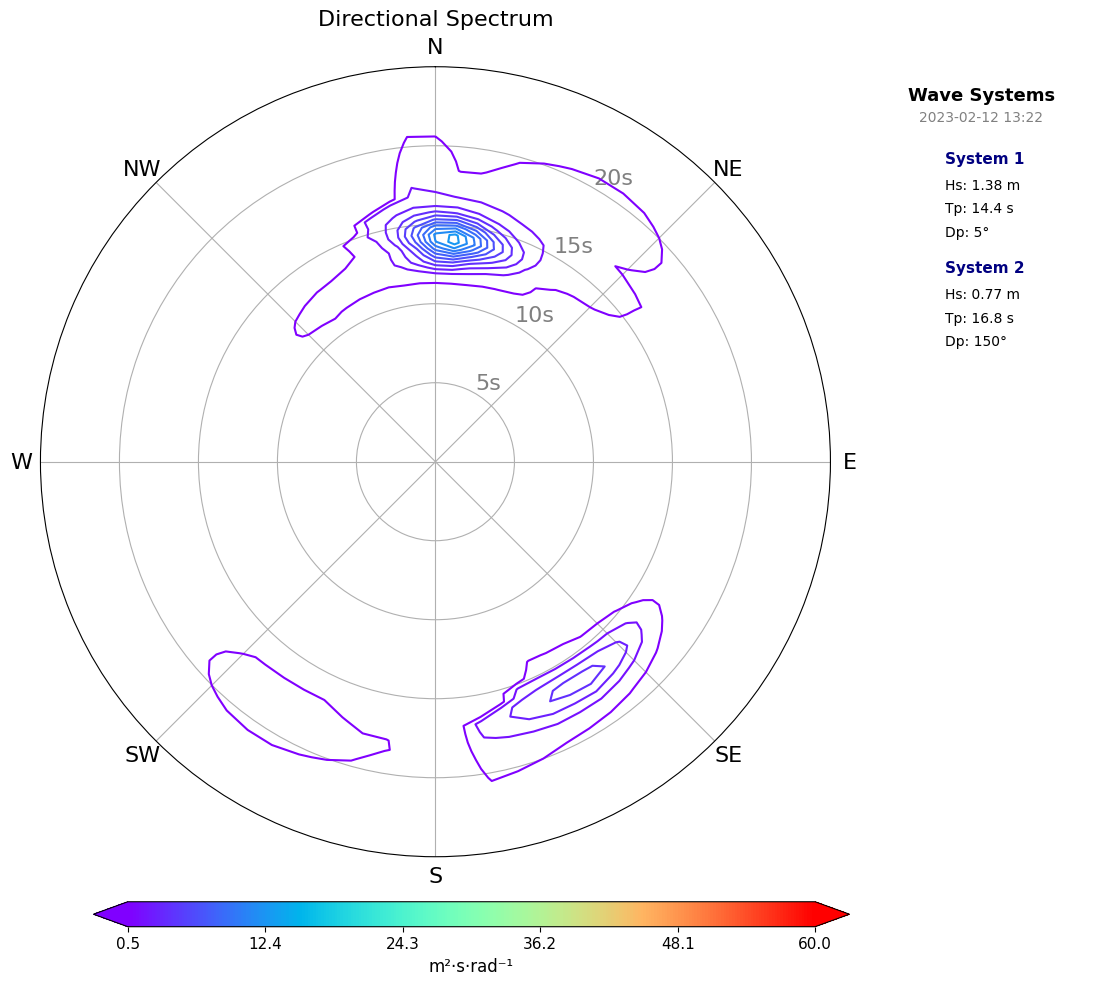

In [17]:
# ============================================================================
# PLOT: Total directional spectrum with identified wave systems
# ============================================================================

# Build partition list for the stats box
partitions_list = None
if results is not None:
    min_e = MIN_ENERGY_THRESHOLD_FRACTION * results['total_m0']
    partitions_list = [
        {'Hs': results['Hs'][i], 'Tp': results['Tp'][i], 'Dp': results['Dp'][i]}
        for i in range(1, len(results['Hs']))
        if results['energy'][i] > min_e
    ]

fig, ax = plot_directional_spectrum(
    E2d,
    freq,
    dirs,
    selected_time=selected_time,
    vmin=CONFIG['plotting']['sar'].get('spectrum_vmin'),
    vmax=CONFIG['plotting']['sar'].get('spectrum_vmax'),
    partitions=partitions_list,
)

plt.show()


## 6. 1D-Spectrum



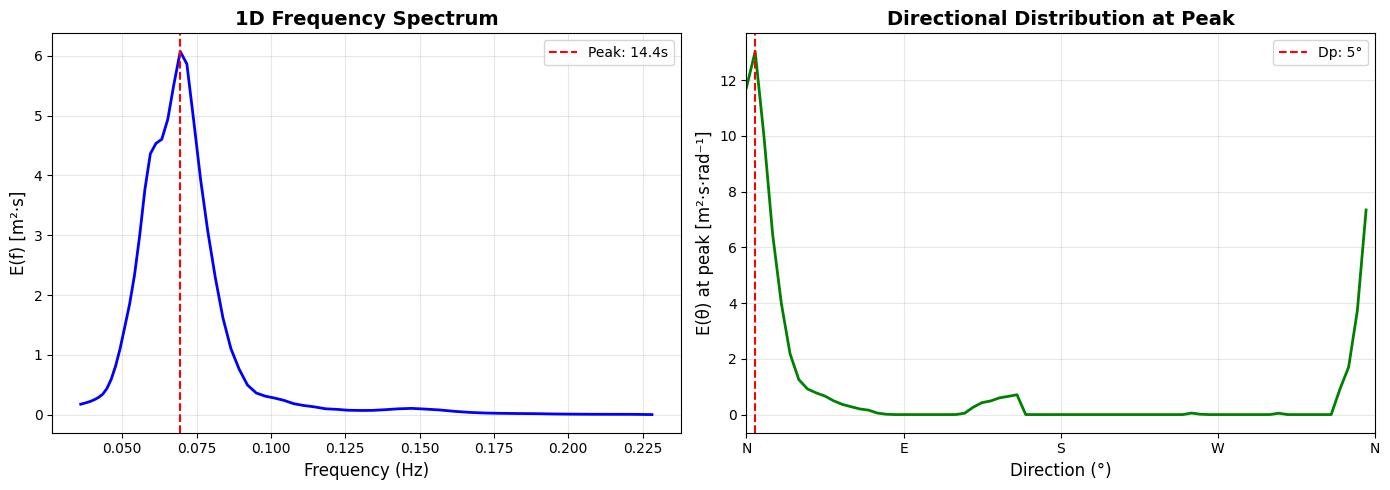

In [18]:
# Calculate 1D spectrum
spec1d, ddir = spectrum1d_from_2d(E2d, dirs_rad)

# Plot 1D spectrum
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Frequency spectrum
ax1.plot(freq, spec1d, 'b-', linewidth=2)
ax1.axvline(freq[i_peak], color='r', linestyle='--', label=f'Peak: {1/freq[i_peak]:.1f}s')
ax1.set_xlabel('Frequency (Hz)', fontsize=12)
ax1.set_ylabel('E(f) [m²·s]', fontsize=12)
ax1.set_title('1D Frequency Spectrum', fontsize=14, weight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Directional distribution at peak
ax2.plot(dirs, E2d[i_peak, :], 'g-', linewidth=2)
ax2.axvline(dp, color='r', linestyle='--', label=f'Dp: {dp:.0f}°')
ax2.set_xlabel('Direction (°)', fontsize=12)
ax2.set_ylabel('E(θ) at peak [m²·s·rad⁻¹]', fontsize=12)
ax2.set_title('Directional Distribution at Peak', fontsize=14, weight='bold')
ax2.set_xlim(0, 360)
ax2.set_xticks([0, 90, 180, 270, 360])
ax2.set_xticklabels(['N', 'E', 'S', 'W', 'N'])
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

## 7. Save Partition Results

Save the partitioning output to CSV for downstream analysis and comparison.


In [19]:

# ============================================================================
# SAVE PARTITION RESULTS
# ============================================================================
output_dir = f'../data/partition-sentinel-{THRESHOLD_PERCENTILE}-{MERGE_FACTOR}'
os.makedirs(output_dir, exist_ok=True)

ref_id = str(index)
min_energy_threshold = MIN_ENERGY_THRESHOLD_FRACTION * results['total_m0']

moments = results['moments']
m0_total = moments['total'][0]
m1_total = moments['total'][1]
m2_total = moments['total'][2]

data = {
    'station_id':   ref_id,
    'obs_time':     selected_time,
    'longitude':    float(lon),
    'latitude':     float(lat),
    'quality_flag': quality_flag,
    'source_file':  os.path.basename(file_path),

    # Total spectrum (from 2D integration)
    'total_energy': results['total_m0'],
    'total_Hs':     results['total_Hs'],
    'total_Tp':     results['total_Tp'],
    'total_Dp':     results['total_Dp'],
    'total_m0':     m0_total,
    'total_m1':     m1_total,
    'total_m2':     m2_total,

    # SAR file reference values (VAVH / VTPK / VPED)
    'sar_Hs':       vavh_sar,
    'sar_Tp':       vtpk_sar,
    'sar_Dp':       vped_sar,
}

# Add partition data (up to 3 partitions)
partition_idx = 0
for i in range(1, len(results['Hs'])):
    if results['energy'][i] > min_energy_threshold:
        partition_idx += 1
        if partition_idx > 3:
            break
        data[f'P{partition_idx}_energy'] = results['energy'][i]
        data[f'P{partition_idx}_Hs']     = results['Hs'][i]
        data[f'P{partition_idx}_Tp']     = results['Tp'][i]
        data[f'P{partition_idx}_Dp']     = results['Dp'][i]
        data[f'P{partition_idx}_m0']     = moments['m0'][i]
        data[f'P{partition_idx}_m1']     = moments['m1'][i]
        data[f'P{partition_idx}_m2']     = moments['m2'][i]

# Fill remaining partitions with zeros
for p in range(partition_idx + 1, 4):
    for key in ['energy', 'Hs', 'Tp', 'Dp', 'm0', 'm1', 'm2']:
        data[f'P{p}_{key}'] = 0.0

# Save
date_str = selected_time.strftime('%Y%m%d-%H%M%S') if selected_time is not None else 'unknown'
output_filename = f'sentinel_{ref_id}_{date_str}.csv'
output_path = os.path.join(output_dir, output_filename)

df_results = pd.DataFrame([data])
df_results.to_csv(output_path, index=False, float_format='%.6f')

print(f"Results saved to: {output_path}")
print(f"\nColumns: {list(df_results.columns)}")
print(f"\nPreview:")
df_results.T


Results saved to: ../data/partition-sentinel-98-0.3/sentinel_18_20230212-132223.csv

Columns: ['station_id', 'obs_time', 'longitude', 'latitude', 'quality_flag', 'source_file', 'total_energy', 'total_Hs', 'total_Tp', 'total_Dp', 'total_m0', 'total_m1', 'total_m2', 'sar_Hs', 'sar_Tp', 'sar_Dp', 'P1_energy', 'P1_Hs', 'P1_Tp', 'P1_Dp', 'P1_m0', 'P1_m1', 'P1_m2', 'P2_energy', 'P2_Hs', 'P2_Tp', 'P2_Dp', 'P2_m0', 'P2_m1', 'P2_m2', 'P3_energy', 'P3_Hs', 'P3_Tp', 'P3_Dp', 'P3_m0', 'P3_m1', 'P3_m2']

Preview:


,0
station_id,18
obs_time,2023-02-12 13:22:23
longitude,-113.51548
latitude,-4.917846
quality_flag,4
source_file,sentinel_sar.nc
total_energy,0.156916
total_Hs,1.584504
total_Tp,14.379167
total_Dp,5.0
